In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
dfA = pd.read_csv('season_summary_A.csv')
dfB = pd.read_csv('season_summary_B.csv')
dfC = pd.read_csv('season_summary_C.csv')

In [8]:
df = pd.concat([dfA, dfB, dfC])

In [9]:
# sort values for plotting
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
df['season'] = pd.Categorical(df['season'], categories=season_order, ordered=True)
df = df.sort_values(['season', 'wind_farm'])

In [10]:
df_wind_pivot = df.pivot(index='season', columns='wind_farm', values='avg_wind_speed')
df_rotor_pivot = df.pivot(index='season', columns='wind_farm', values='avg_rotor_speed')

In [34]:
farms = ['A', 'B', 'C']
colors = ['#E8F4C8', '#F7D9C4', '#C7E6F4']
def plot_df(df_pivot, ylabel):
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(df_pivot.index))
    width = 0.25
    offsets = [-width, 0, width]
    for i in range(3):
        ax.bar(x + offsets[i], df_pivot[farms[i]], width, label=farms[i], color=colors[i], edgecolor='black')
    ax.set_xlabel('Season')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} by Season and Wind Farm')
    ax.set_xticks(x)
    ax.set_xticklabels(df_pivot.index)
    fig.legend(loc='outside right', title='Wind Farm')
    

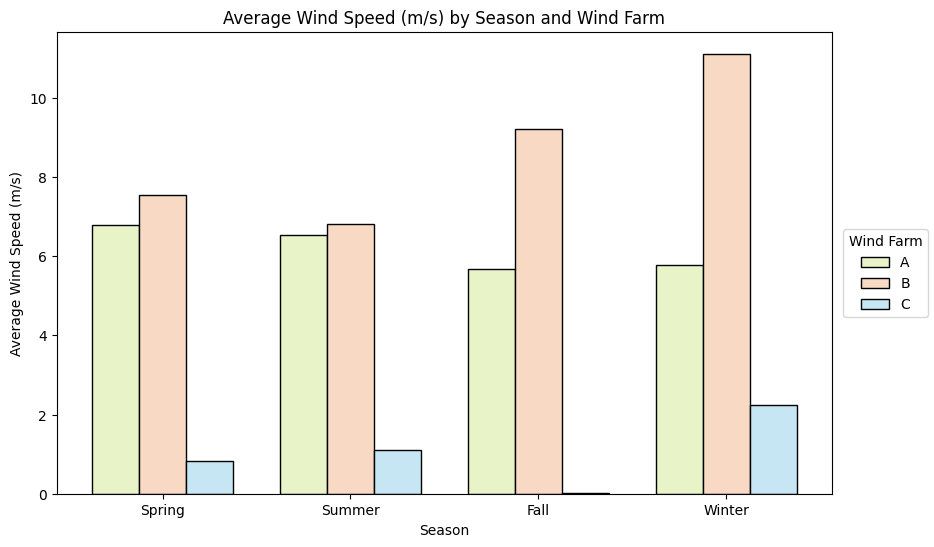

In [36]:
plot_df(df_wind_pivot, 'Average Wind Speed (m/s)')

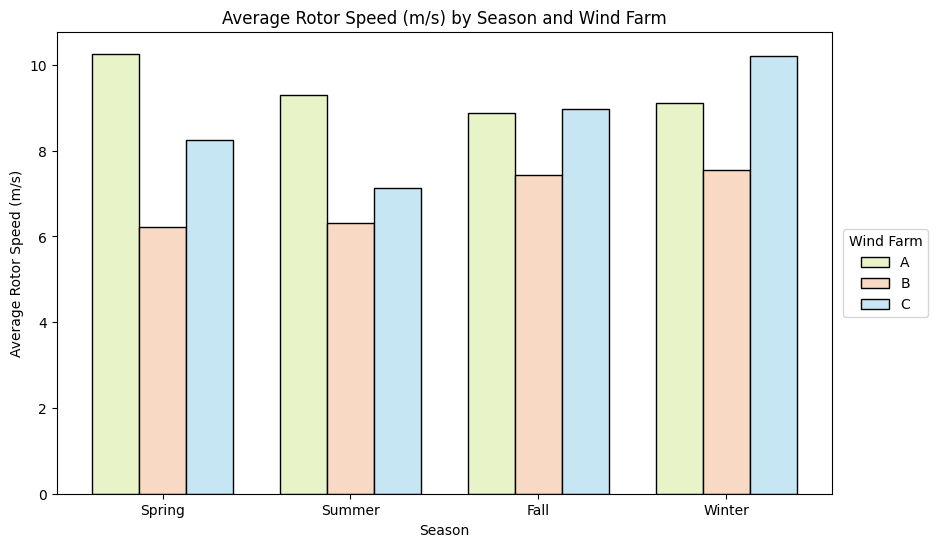

In [37]:
plot_df(df_rotor_pivot, 'Average Rotor Speed (m/s)')